In [1]:
import os
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Device Selection (GPU/CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Training auf GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Training auf CPU (Langsam!)")

def read_pfm(file):
    with open(file, "rb") as f:
        header = f.readline().decode('utf-8').rstrip()
        if header == 'PF':
            color = True
        elif header == 'Pf':
            color = False
        else:
            raise Exception('Keine PFM Datei.')

        dims = f.readline().decode('utf-8').split()
        width = int(dims[0])
        height = int(dims[1])

        scale = float(f.readline().decode('utf-8').rstrip())
        # Negativer Scale bedeutet Little Endian (Standard bei SceneFlow)
        if scale < 0:
            endian = '<'
            scale = -scale
        else:
            endian = '>'

        data = np.fromfile(f, endian + 'f')
        shape = (height, width, 3) if color else (height, width)

        data = np.reshape(data, shape)
        data = np.flipud(data) # PFM speichert von unten nach oben
        
        # WICHTIG: Inf-Werte abfangen
        data[data == np.inf] = 0
        
        return data.copy()

    return data

Training auf GPU: NVIDIA GeForce RTX 3080 Ti


In [2]:
def visualize_cost_volume(cv, d, title="Cost Volume Slice"):
    # cv: [1, C*D, H, W]
    C = 32
    slice_d = cv[0, d*C:(d+1)*C].mean(dim=0).cpu().numpy()

    plt.figure(figsize=(6,4))
    plt.imshow(slice_d, cmap='inferno')
    plt.title(f"{title} (d={d})")
    plt.colorbar()
    plt.show()


In [3]:
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import transforms
import torchvision.transforms.functional as TF
import random

class StereoDataset(torch.utils.data.Dataset):
    def __init__(self, left_dir, right_dir, disp_dir, training=True):
        self.left_paths = sorted([os.path.join(left_dir, f) for f in os.listdir(left_dir) if f.endswith('.png')])
        self.right_paths = sorted([os.path.join(right_dir, f) for f in os.listdir(right_dir) if f.endswith('.png')])
        self.disp_paths = sorted([os.path.join(disp_dir, f) for f in os.listdir(disp_dir) if f.endswith('.pfm')])
        self.training = training
        # Basis-Transform für die Konvertierung in Tensoren
        self.transform = transforms.Compose([
            transforms.Grayscale(1),
            transforms.Resize((480, 640)),
            transforms.ToTensor(),
        ])
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.left_paths)

    def augment(self, left, right, disp):
        # 1. Zufälliges horizontales Flipping (Vorsicht: Links/Rechts tauschen!)
        #if random.random() > 0.5: 
        #    left = TF.hflip(left) 
        #    right = TF.hflip(right) 
        #    disp = TF.hflip(disp) # Disparität invertieren: d_new = max_disp - d_old 
        #    disp = 1.0 - disp # weil normiert 
        

        # 2. Helligkeits-Varianz (Simuliert unterschiedliche Belichtung der Sensoren)
        # Wir wenden dies leicht unterschiedlich auf beide Bilder an
        if random.random() > 0.2:
            brightness_l = random.uniform(0.8, 1.2)
            brightness_r = random.uniform(0.8, 1.2)
            left = TF.adjust_brightness(left, brightness_l)
            right = TF.adjust_brightness(right, brightness_r)

        # 3. Sensor-Rauschen (Gaußsches Rauschen für Low-Light Simulation)
        if random.random() > 0.5:
            noise_sigma = random.uniform(0, 0.03)
            left = torch.clamp(left + torch.randn_like(left) * noise_sigma, 0, 1)
            right = torch.clamp(right + torch.randn_like(right) * noise_sigma, 0, 1)

        return left, right, disp

    def __getitem__(self, idx):
        # 1. Bilder laden
        left_img = Image.open(self.left_paths[idx]).convert('L')
        right_img = Image.open(self.right_paths[idx]).convert('L')
        
        # 2. Bilder auf Zielgröße bringen (Das hat gefehlt!)
        left_img = left_img.resize((640, 480), Image.BILINEAR)
        right_img = right_img.resize((640, 480), Image.BILINEAR)
        
        # 3. In Tensoren wandeln [0.0, 1.0]
        left = self.to_tensor(left_img)
        right = self.to_tensor(right_img)

        # 4. PFM Disparität laden & Vorzeichen-Korrektur
        disp_np = read_pfm(self.disp_paths[idx])
        disp_np = np.abs(disp_np)
        disp_np[~np.isfinite(disp_np)] = 0
        
        # 5. Skalierung der Disparitätswerte (Wichtig!)
        # scale_factor muss auf die Original-Breite des PFM (960) bezogen sein
        original_width = disp_np.shape[1]
        scale_factor = 640.0 / original_width
        disp = torch.from_numpy(disp_np.copy()).float().unsqueeze(0)
        disp = disp * scale_factor
        
        # 6. Resizing der Disparität auf 480x640
        disp = F.interpolate(disp.unsqueeze(0), size=(480, 640), mode='nearest').squeeze(0)

        # 7. Augmentation (jetzt auf 480x640 Tensoren)
        if self.training:
            left, right, disp = self.augment(left, right, disp)

        # 8. Normalisierung auf Bereich [0, 1] basierend auf MAX_DISP=192
        disp_norm = torch.clamp(disp / 192.0, 0, 1)

        return left, right, disp_norm

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride,
                            padding=1, groups=in_ch, bias=False)
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=1,
                            padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn1(self.dw(x)))
        x = self.relu(self.bn2(self.pw(x)))
        return x


class DWResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1,
                      groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(out_ch)
        )

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv(x)
        out += self.shortcut(x)
        return self.relu(out)


class StereoNetLitePP(nn.Module):
    def __init__(self, max_disp=192):
        super().__init__()
        self.max_disp = max_disp
        self.cost_vol_shifts = max_disp // 4  # 48 bei 1/4-Resolution

        # 1. Feature Extractor (1/4-Resolution)
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            DWResidualBlock(16, 32, stride=2),  # 1/2
            DWResidualBlock(32, 32, stride=2)   # 1/4
        )

        # 2. Cost Volume Aggregator (Matching über |L - R_shift|)
        in_cv_ch = 32 * self.cost_vol_shifts
        self.aggregator = nn.Sequential(
            DepthwiseSeparableConv(in_cv_ch, 128),
            DepthwiseSeparableConv(128, 64),
            DepthwiseSeparableConv(64, 32),
            nn.Conv2d(32, 1, kernel_size=3, padding=1, bias=False)
        )

        # 3. Refinement (left + right + disp_norm)
        self.refine = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            DWResidualBlock(32, 32),
            DWResidualBlock(32, 16),
            nn.Conv2d(16, 1, kernel_size=3, padding=1, bias=False),
            #nn.ReLU(inplace=True)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def build_cost_volume(self, feat_l, feat_r):
        """
        Cost-Volume über horizontale Shifts des rechten Features:
        cv[d] = |feat_l - shift_r(d)|, wobei d = 0..D (Shift nach links)
        """
        B, C, H, W = feat_l.shape
        volume = []
        for d in range(self.cost_vol_shifts):
            if d == 0:
                shifted_r = feat_r
            else:
                # Shift rechtes Feature um d Pixel nach links
                shifted_r = F.pad(feat_r[:, :, :, d:], (0, d, 0, 0), mode='constant', value=0)
            cost = torch.abs(feat_l - shifted_r)
            volume.append(cost)
        return torch.cat(volume, dim=1)  # [B, C*D, H, W]


    def forward(self, left, right):
        # 1. Features
        feat_l = self.feature_extractor(left)
        feat_r = self.feature_extractor(right)

        # 2. Cost Volume + Aggregation (1/4-Res Disparität)
        cv = self.build_cost_volume(feat_l, feat_r)
        disp_4 = self.aggregator(cv)  # [B,1,H/4,W/4]

        # 3. Upsampling + Skalierung in Pixel
        disp_low = F.interpolate(disp_4, scale_factor=4,
                                 mode='bilinear', align_corners=True)
        disp_low = disp_low * 4.0  # 1/4→1.0 Pixel-Skala

        # 4. Refinement mit normierter Disparität + beiden Bildern
        disp_norm = disp_low / self.max_disp
        combined = torch.cat([left, right, disp_norm], dim=1)
        final_disp = self.refine(combined)  # [B,1,H,W], Pixel-normiert (0..1)

        # final_disp ist normiert (0..1) → für Loss direkt nutzbar
        return final_disp


In [5]:
import torch.nn.functional as F

def warp(right_img, disp):
    """
    Rekonstruiert das linke Bild aus dem rechten Bild und der Disparität.
    Erwartet: disp in Pixelkoordinaten (nicht normiert).
    """
    B, C, H, W = right_img.size()

    # Erzeuge Basis-Gitter in Pixelkoordinaten
    grid_x, grid_y = torch.meshgrid(
        torch.arange(W, device=right_img.device),
        torch.arange(H, device=right_img.device),
        indexing='xy'
    )
    grid_x = grid_x.unsqueeze(0).expand(B, -1, -1).float()
    grid_y = grid_y.unsqueeze(0).expand(B, -1, -1).float()

    # Verschiebe X-Koordinaten um Disparität (rechtes Bild → linkes Bild)
    shifted_x = grid_x - disp.squeeze(1)  # Disparität abziehen

    # Normiere auf [-1, 1] für grid_sample
    norm_x = 2.0 * shifted_x / (W - 1) - 1.0
    norm_y = 2.0 * grid_y / (H - 1) - 1.0

    vgrid = torch.stack((norm_x, norm_y), dim=3)

    return F.grid_sample(right_img, vgrid, mode='bilinear', padding_mode='border', align_corners=True)

def stereo_loss(pred_disp, gt_disp, max_disp=192):
    """
    Optimierter Loss für Lite++ mit Fokus auf Nahbereich.
    """
    mask = (gt_disp > 0) & (gt_disp < 1.0) # Gültige Pixel innerhalb des Bereichs
    
    if not mask.any():
        return torch.tensor(0.0, device=pred_disp.device, requires_grad=True)

    # Huber Loss ist stabiler als reines L1
    base_loss = F.smooth_l1_loss(pred_disp[mask], gt_disp[mask], reduction='none')
    
    # Nahbereichs-Boost: Pixel mit hoher Disparität (nah) werden stärker gewichtet.
    # Da gt_disp normiert ist (0..1), ist gt_disp=1.0 der nahstmögliche Punkt.
    weights = 1.0 + gt_disp[mask] * 3.0 # Erhöht die Gewichtung für nahe Objekte bis zu 4-fach
    
    return (base_loss * weights).mean()

import torch
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast

def train_production(model, loader, test_dataset, epochs=50, lr=5e-4, start_epoch=0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    # Der Scaler verhindert, dass kleine Gradienten in FP16 auf Null "untergehen"
    scaler = GradScaler()

    os.makedirs("training_progress", exist_ok=True)
    model.train()
    print(f"Starte Training auf {device} (mit Mixed Precision)...")

    for epoch in range(start_epoch, epochs):
        epoch_loss = 0
        
        for i, (left, right, target) in enumerate(tqdm(loader, desc=f"Epoch {epoch+1}")):
            left, right, target = left.to(device), right.to(device), target.to(device)

            optimizer.zero_grad()
            
            # Autocast übernimmt die Umwandlung in FP16 für Vorwärtspass und Loss
            with autocast():
                output = model(left, right)
                # Falls dein Modell mehrere Outputs liefert (Refinement), nimm den letzten
                if isinstance(output, (list, tuple)):
                    loss = sum([stereo_loss(out / model.max_disp, target) for out in output])
                else:
                    loss = stereo_loss(output / model.max_disp, target)

            # Der Scaler skaliert den Loss hoch, bevor backward() aufgerufen wird
            scaler.scale(loss).backward()
            
            # Unscale und Optimizer Step
            scaler.step(optimizer)
            
            # Update für den nächsten Schritt
            scaler.update()
            
            epoch_loss += loss.item()
            
            #if i % 100 == 0:
            #    # Vorschau-Bilder werden weiterhin normal erstellt
            #    save_preview(model, test_dataset, f"{epoch+1}_batch_{i}", index=6, warp_func=warp)

        avg_loss = epoch_loss / len(loader)
        scheduler.step(avg_loss)
        
        # --- EPOCHEN-CHECKPOINT & VORSCHAU ---
        save_preview(model, test_dataset, f"epoch_{epoch+1}_final", index=6, warp_func=warp)
        torch.save(model.state_dict(), f"stereo_model_plusplus_CP_epoch_{epoch+1}.pth")
        
        curr_lr = optimizer.param_groups[0]['lr']
        print(f">>> ENDE EPOCHE {epoch+1} | Avg Loss: {avg_loss:.6f} | LR: {curr_lr:.8f}")
        torch.cuda.empty_cache()

def save_preview(model, dataset, name, index=6, warp_func=None):
    """ 
    Erstellt eine Vorhersage inklusive Warp-Rekonstruktion 
    und speichert sie als PNG. 
    """
    model.eval()
    with torch.no_grad():
        # Ein Bildpaar und GT aus dem Dataset holen
        left, right, target = dataset[index]
        left_in = left.unsqueeze(0).to(device)
        right_in = right.unsqueeze(0).to(device)
        
        # Vorhersage
        pred = model(left_in, right_in)
        if isinstance(pred, (list, tuple)):
            pred = pred[-1] 
            
        # Warp-Rekonstruktion (Linkes Bild aus rechtem Bild + Pred)
        # Wir brauchen das Bild auf dem richtigen Device
        recon_left = None
        if warp_func is not None:
            recon_left = warp_func(right_in, pred)
            recon_left = recon_left.squeeze().cpu().numpy()

        pred_np = (pred / model.max_disp).squeeze().cpu().numpy()
        gt_np = target.squeeze().cpu().numpy()
        left_np = left.squeeze().cpu().numpy()
        
        # Plotting: 1 Zeile, 3 Spalten
        fig, ax = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Ground Truth
        ax[0].imshow(gt_np, cmap='jet', vmin=0, vmax=1.0)
        ax[0].set_title(f"GT (Index {index})")
        
        # 2. Vorhersage
        ax[1].imshow(pred_np, cmap='jet', vmin=0, vmax=1.0)
        ax[1].set_title(f"Vorhersage: {name}")
        
        # 3. Warp-Check oder Original-Links Vergleich
        if recon_left is not None:
            ax[2].imshow(recon_left, cmap='gray')
            ax[2].set_title("Warp-Rekonstruktion")
        else:
            ax[2].imshow(left_np, cmap='gray')
            ax[2].set_title("Original Links (Referenz)")
        
        # Verzeichnis sicherstellen und speichern
        import os
        os.makedirs("training_progress", exist_ok=True)
        plt.savefig(f"training_progress/CP_preview_{name}.png", bbox_inches='tight')
        plt.close(fig) 
        
    model.train()

# Aufruf auf der 3080 Ti
# train_production(model, train_loader, dataset, epochs=50)

In [6]:
import time
import matplotlib.pyplot as plt

def check_dataset_sanity(dataset, index=0):
    print(f"--- Sanity Check: Index {index} ---")
    start_time = time.time()
    
    try:
        # Versuche ein einzelnes Item zu laden
        left, right, disp = dataset[index]
        load_time = time.time() - start_time
        
        print(f"✓ Erfolgreich geladen in {load_time:.4f} Sekunden")
        print(f"✓ Shape Left: {left.shape}")
        print(f"✓ Shape Disp: {disp.shape}")
        print(f"✓ Max Disp im Bild: {disp.max():.2f}")

        # Visualisierung
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        # Left Image (muss eventuell von Tensor [C,H,W] zurück nach [H,W,C] für plt)
        img_display = left.permute(1, 2, 0).numpy()
        # Normalisierung für Anzeige falls nötig
        if img_display.max() > 1.0: img_display = img_display / 255.0
        
        ax[0].imshow(img_display, cmap='gray') # Explizit 'gray' nutzen!
        ax[0].set_title("Eingangsbild (Graustufen IMX296)")
        
        # Disparität
        # vmin und vmax erzwingen, dass 0.0 Blau und 1.0 Rot ist
        ax[1].imshow(disp.squeeze().numpy(), cmap='jet', vmin=0, vmax=1.0)
        ax[1].set_title("Korrektes Tiefenbild (Invertiert)")
        plt.show()

    except Exception as e:
        print(f"❌ FEHLER beim Laden von Index {index}:")
        print(e)

# Aufruf
# check_dataset_sanity(dataset, index=0)

--- Sanity Check: Index 0 ---
✓ Erfolgreich geladen in 0.0601 Sekunden
✓ Shape Left: torch.Size([1, 480, 640])
✓ Shape Disp: torch.Size([1, 480, 640])
✓ Max Disp im Bild: 0.53


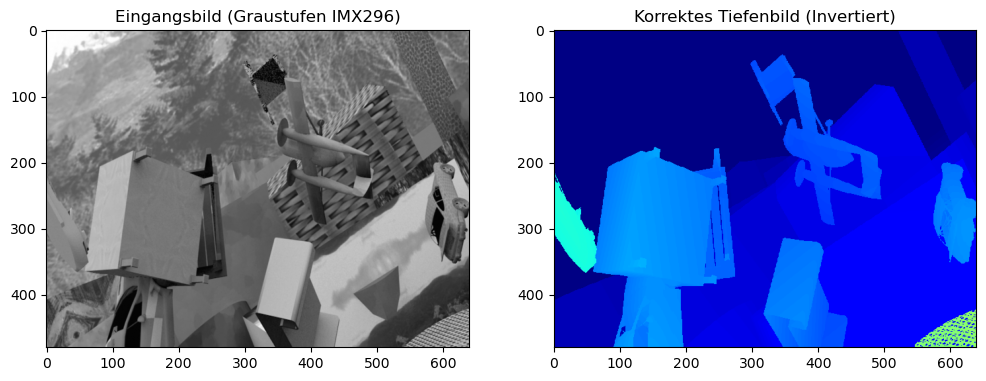

/tmp/ipykernel_34216/3233270041.py:59: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Starte Training auf cuda (mit Mixed Precision)...


Epoch 1:   0%|                                                                       | 0/2607 [00:00<?, ?it/s]/tmp/ipykernel_34216/3233270041.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1:  15%|█████████▍                                                   | 403/2607 [01:10<05:58,  6.14it/s]

In [ ]:
def main():
    torch.cuda.empty_cache()
    # 1. Datensatz und Loader vorbereiten
    # 'training=True' aktiviert deine Augmentations
    dataset = StereoDataset(
        left_dir='/mnt/c/temp/sceneflow/left', 
        right_dir='/mnt/c/temp/sceneflow/right', 
        disp_dir='/mnt/c/temp/sceneflow/disp',
        training=False #True = Augmenting aktiv 
    )

    # Sanity Check (optional, aber gut vor dem Start)
    check_dataset_sanity(dataset, index=0)

    # Loader mit mehreren Workern
    # Für Windows: num_workers=4 oder 8 ist meist der Sweetspot bei einer 3080 Ti
    train_loader = torch.utils.data.DataLoader(
        dataset, 
        batch_size=10, 
        shuffle=True, 
        num_workers=8,           # Jetzt sicher nutzbar
        pin_memory=True, 
        persistent_workers=True, # Auf True setzen, wenn workers > 0
        prefetch_factor=4        # Lädt batches im Voraus
    )

    # 2. Modell initialisieren
    
    model = StereoNetLitePP(max_disp=192).to(device)
    
    last_epoch = 0 
    if last_epoch != 0:
        checkpoint_path = f"stereo_model_plusplus_CP_epoch_{last_epoch}.pth"
        if os.path.exists(checkpoint_path):
            model.load_state_dict(torch.load(checkpoint_path))
            print(f"Checkpoint {checkpoint_path} erfolgreich geladen.")

    # 3. Training starten
    train_production(
        model, 
        train_loader, 
        test_dataset=dataset, 
        epochs=25, 
        lr=5e-4,
        start_epoch=last_epoch
    )

if __name__ == '__main__':
    # In Jupyter Notebooks kann es manchmal zu Problemen kommen, 
    # wenn main() direkt aufgerufen wird, aber für Multiprocessing 
    # ist dieser Schutz die einzige saubere Lösung.
    main()

In [ ]:
def quick_check(model_path, dataset, index=0):
    # WICHTIG: Hier muss max_disp=128 stehen, passend zu deinem Training!
    model = StereoNetLite(max_disp=128).to(device) 
    
    # Jetzt passt die State-Dict Form wieder zusammen
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    left, right, target = dataset[index]
    left_in = left.unsqueeze(0).to(device)
    right_in = right.unsqueeze(0).to(device)
    
    with torch.no_grad():
        prediction = model(left_in, right_in).squeeze().cpu().numpy()
    
    # Visualisierung (mit korrekter Skalierung für 128)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title("Eingang (Links)")
    plt.imshow(left.squeeze(), cmap='gray')
    
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth (PFM)")
    # Rückskalierung auf Pixel-Werte für die Anzeige
    plt.imshow(target.squeeze() * 128, cmap='jet', vmin=0, vmax=128)
    plt.colorbar(label='Pixel Shift')
    
    plt.subplot(1, 3, 3)
    plt.title("Vorhersage (Model)")
    plt.imshow(prediction * 128, cmap='jet', vmin=0, vmax=128)
    plt.colorbar(label='Pixel Shift')
    plt.show()

# Aufruf:
dataset = HailoStereoDataset(
        left_dir='C:/daten/sceneflow/data/left', 
        right_dir='C:/daten/sceneflow/data/right', 
        disp_dir='C:/daten/sceneflow/data/disp'
    )
quick_check("hailo_stereo_model.pth", dataset, index=0)

In [ ]:
# Wir nehmen das erste Bild aus deinem bereits initialisierten 'dataset' Objekt
dataset = StereoDataset(
        left_paths='C:/daten/sceneflow/data/left', 
        right_paths='C:/daten/sceneflow/data/right', 
        disp_paths='C:/daten/sceneflow/data/disp'
    )
idx = 0
pfm_path = dataset.disp_paths[idx]
disp_data = read_pfm(pfm_path)

print(f"Datei: {os.path.basename(pfm_path)}")
print(f"Max Disparität im PFM: {disp_data.max():.2f}")
print(f"Min Disparität im PFM: {disp_data.min():.2f}")
print(f"Durchschnitt: {disp_data.mean():.2f}")

In [ ]:
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            torch.nn.init.constant_(m.bias, 0)

# 1. Modell komplett neu instanziieren (für 128 Pixel)
model = StereoNetLite(max_disp=128).to(device)
model.apply(weights_init)

# 2. Lernrate zurücksetzen auf Startwert
# Wir nehmen 5e-4 für einen schnellen Overfit-Test
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# 3. Scheduler neu aufsetzen
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

print("Modell wurde zurückgesetzt und ist bereit für den 128er Overfit-Test.")

In [ ]:
import tarfile
import shutil
import os
from pathlib import Path

def setup_sceneflow_dataset(archive_path, extract_to):
    """
    Entpackt SceneFlow Archive und sortiert sie in eine flache Struktur.
    archive_path: Pfad zur .tar oder .tar.bz2 Datei
    extract_to: Zielordner (z.B. 'C:/daten/sceneflow_final')
    """
    temp_dir = Path(extract_to) / "temp_extraction"
    final_dir = Path(extract_to)
    
    # Ordner erstellen
    for sub in ["left", "right", "disp"]:
        (final_dir / sub).mkdir(parents=True, exist_ok=True)

    print(f"Extrahiere {archive_path}...")
    with tarfile.open(archive_path, "r:*") as tar:
        tar.extractall(path=temp_dir)

    print("Sortiere Dateien...")
    # Wir suchen rekursiv nach den relevanten Dateien
    for root, dirs, files in os.walk(temp_dir):
        for file in files:
            source_path = Path(root) / file
            
            # Zielpfad bestimmen basierend auf Ordnernamen im Archiv
            if "left" in root.lower() and file.endswith((".png", ".jpg")):
                target_path = final_dir / "left" / file
            elif "right" in root.lower() and file.endswith((".png", ".jpg")):
                target_path = final_dir / "right" / file
            elif file.endswith(".pfm"):
                target_path = final_dir / "disp" / file
            else:
                continue
            
            # Falls Dateiname schon existiert (z.B. 0001.png in versch. Unterordnern), 
            # hängen wir den Ordnernamen davor
            if target_path.exists():
                parent_name = source_path.parent.parent.name # z.B. '15mm_focallength'
                target_path = target_path.parent / f"{parent_name}_{file}"
            
            shutil.move(str(source_path), str(target_path))

    # Temp-Ordner löschen
    shutil.rmtree(temp_dir)
    print(f"Fertig! Daten liegen in: {final_dir}")

# BEISPIEL ANWENDUNG (Pfade anpassen):
setup_sceneflow_dataset("C:/temp/FlyingThings3D_subset_image_clean.tar.bz2", "C:/temp/sceneflow")
setup_sceneflow_dataset("C:/temp/FlyingThings3D_subset_disparity.tar.bz2", "C:/temp/sceneflow")

In [ ]:
def validate_on_cpu(checkpoint_path, test_dataset):
    # 1. Modell-Instanz erstellen und auf CPU lassen
    val_model = StereoNetLitePlus(max_disp=128).cpu() 
    
    # 2. Den letzten gespeicherten Stand laden
    val_model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
    val_model.eval()
    
    # 3. Test-Loader (kleinerer Batch für CPU)
    val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, num_workers=0)
    
    total_epe = 0
    with torch.no_grad():
        for left, right, target in tqdm(val_loader, desc="CPU-Validierung"):
            output = val_model(left, right)
            if isinstance(output, (list, tuple)):
                output = output[-1]
            
            # EPE Berechnung (alles auf CPU)
            pred_disp = output * 128
            gt_disp = target * 128
            
            mask = gt_disp > 0
            if mask.sum() > 0:
                total_epe += torch.abs(pred_disp[mask] - gt_disp[mask]).mean().item()
                
    print(f"EPE für {checkpoint_path}: {total_epe/len(val_loader):.4f}")

# Aufruf während das Training läuft (z.B. für Epoche 7):
dataset = HailoStereoDataset(
            left_dir='C:/temp/sceneflow/left', 
            right_dir='C:/temp/sceneflow/right', 
            disp_dir='C:/temp/sceneflow/disp'
            )
validate_on_cpu("stereo_model_plus_epoch_22.pth", dataset)

In [ ]:
def validate_on_gpu_centered(checkpoint_path, test_dataset, max_disp=128):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    val_model = StereoNetLitePlus(max_disp=max_disp).to(device)
    val_model.load_state_dict(torch.load(checkpoint_path))
    val_model.eval()
    
    val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8, num_workers=0)
    
    total_epe = 0
    valid_batches = 0
    
    # Ränder definieren, die ignoriert werden (in Pixeln)
    # Links schneiden wir die volle max_disp ab, da dort keine Korrespondenz möglich ist
    border_l, border_r = max_disp, 20
    border_t, border_b = 20, 20

    with torch.no_grad():
        for left, right, target in tqdm(val_loader, desc="Zentrale Validierung"):
            left, right, target = left.to(device), right.to(device), target.to(device)
            output = val_model(left, right)
            
            if isinstance(output, (list, tuple)):
                output = output[-1]
            
            pred_disp = output * max_disp
            gt_disp = target * max_disp
            
            # Maske für gültige Ground-Truth Pixel
            mask = gt_disp > 0
            
            # Rand-Maske erstellen (Zentraler Bereich = 1, Rand = 0)
            h, w = gt_disp.shape[-2:]
            center_mask = torch.zeros_like(gt_disp)
            center_mask[:, :, border_t:h-border_b, border_l:w-border_r] = 1
            
            # Kombinierte Maske
            final_mask = mask * center_mask
            
            if final_mask.sum() > 0:
                total_epe += torch.abs(pred_disp[final_mask] - gt_disp[final_mask]).mean().item()
                valid_batches += 1
                
    avg_epe = total_epe / valid_batches if valid_batches > 0 else 0
    print(f"\n>>> Center-EPE (ohne Randfehler): {avg_epe:.4f} Pixel")
    
    del val_model
    torch.cuda.empty_cache()
    return avg_epe

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def save_error_heatmap(checkpoint_path, test_dataset, epoch, max_disp=128):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    val_model = StereoNetLitePlus(max_disp=max_disp).to(device)
    val_model.load_state_dict(torch.load(checkpoint_path))
    val_model.eval()
    
    # Wir nehmen ein einzelnes Beispiel aus dem Dataset
    left, right, target = test_dataset[0] # Index 10 als Beispiel
    left_t = left.unsqueeze(0).to(device)
    right_t = right.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = val_model(left_t, right_t)
        if isinstance(output, (list, tuple)):
            output = output[-1]
        
        pred_disp = (output[0, 0] * max_disp).cpu().numpy()
        gt_disp = (target[0] * max_disp).numpy()
    
    # Maske für gültige Daten
    mask = gt_disp > 0
    
    # Absoluter Fehler berechnen
    error_map = np.abs(pred_disp - gt_disp)
    error_map[~mask] = 0 # Ignoriere ungültige GT-Pixel
    
    # Visualisierung
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Vorhersage")
    plt.imshow(pred_disp, cmap='jet')
    plt.colorbar()
    
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(gt_disp, cmap='jet')
    plt.colorbar()
    
    plt.subplot(1, 3, 3)
    plt.title("Fehler-Heatmap (EPE)")
    # vmin/vmax begrenzt die Skala (z.B. 0 bis 10 Pixel Fehler)
    plt.imshow(error_map, cmap='hot', vmin=0, vmax=10)
    plt.colorbar(label='Pixel Abweichung')
    
    plt.savefig(f"error_analysis_epoch_{epoch}.png")
    plt.show()

# Aufruf:
save_error_heatmap("stereo_model_plus_epoch_22.pth", dataset, 22)